# Part A — Exploratory Survival Analysis (Prepayment)

This notebook produces, for the 30-year fixed-rate Freddie Mac panel:

  **(i)** Kaplan-Meier survival estimates for prepayment.
  **(ii)** Implied hazard rates (discrete monthly + smoothed continuous).
  **(iii)** Stratified survival/hazard curves and log-rank tests across FICO,
       LTV, DTI, and vintage.

Every plot is rendered inline AND saved to `../figures/` as PNG so it can be
dropped straight into the presentation. All bin breakpoints sit in a single
config dict at the top of the notebook — change the values there to slice
the data however you like.

**Prepayment** is defined here as `event_type == "prepaid"` (`zb_code` 01,
full payoff). Default, other terminations, and censored loans are all
treated as censored for prepayment-survival purposes.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from lifelines.statistics import multivariate_logrank_test
from lifelines.utils import survival_table_from_events

from src.credit_data import load_loans

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
print("repo:", REPO_ROOT)
print("figures →", FIGURES_DIR)

repo: c:\Users\a\Desktop\Credit\Project2
figures → c:\Users\a\Desktop\Credit\Project2\figures


## Configuration

`COVARIATE_BINS` defines the bin breaks and labels for each covariate. Change a
list to use your own bins — the rest of the notebook respects whatever you put
here.

`YEARS` selects vintages to include in the analysis. Default is 2006-2022:
2023+ is excluded because 2023 H2 is missing upstream and 2024-2025 are
recommended as held-out test data.

In [2]:
YEARS = list(range(2006, 2023))   # in-sample vintages

# Each covariate config: bin breaks (interior cut points) + labels (one more
# than breaks). Edit freely — the rest of the notebook just reads from here.
COVARIATE_BINS = {
    "fico": {
        "breaks": [660, 700, 740, 780],
        "labels": ["<660", "660-700", "700-740", "740-780", "780+"],
    },
    "ltv": {
        "breaks": [60, 80, 90, 95],
        "labels": ["≤60", "60-80", "80-90", "90-95", "95+"],
    },
    "dti": {
        "breaks": [30, 40, 45],
        "labels": ["≤30", "30-40", "40-45", "45+"],
    },
}

# Vintage groups handled separately because we want raw years, not bins.
VINTAGE_GROUPS = {
    "2006-2008 (crisis)":  [2006, 2007, 2008],
    "2009-2014 (recovery)": [2009, 2010, 2011, 2012, 2013, 2014],
    "2015-2019 (low-rate)": [2015, 2016, 2017, 2018, 2019],
    "2020-2022 (covid)":    [2020, 2021, 2022],
}

MAX_MONTHS = 240   # truncate KM/hazard plots at this horizon (20 years)
SMOOTH_BW  = 3     # months bandwidth for the centered rolling-mean smoother

# Stratified analyses subsample per group to bound RAM. KM converges well
# below 1M rows, and log-rank chi-squared scales linearly in n so the
# cross-covariate ranking is preserved. Set to None for full-precision plots
# if you have plenty of RAM; raise the cap if you want tighter curves.
SAMPLE_PER_GROUP = 500_000

## Load loan-level features and prepayment label

`load_loans()` is origination LEFT JOIN outcomes on `loan_seq_num` — exactly
what's needed for KM (one row per loan with its features and its event).

In [3]:
# Load only the columns we use downstream. Dropping loan_seq_num saves
# ~260 MB on a 13M-row pull; event_type is dropped after deriving the
# binary prepay_observed indicator.
loans = (
    load_loans(
        years=YEARS,
        columns=["vintage_year", "fico", "ltv", "dti", "event_type", "event_time_months"],
    )
    .with_columns(
        (pl.col("event_type") == "prepaid").cast(pl.Int8).alias("prepay_observed"),
    )
    .filter(pl.col("event_time_months").is_not_null())
)
print(f"loans loaded: {loans.height:,} rows over {len(YEARS)} vintages")
print("event_type distribution:")
print(loans.group_by("event_type").len().sort("len", descending=True))
print(f"\nprepayment rate (overall): {loans['prepay_observed'].mean():.3f}")
loans = loans.drop("event_type")  # done with it

loans loaded: 23,212,251 rows over 17 vintages
event_type distribution:


shape: (4, 2)
┌───────────────────┬──────────┐
│ event_type        ┆ len      │
│ ---               ┆ ---      │
│ str               ┆ u32      │
╞═══════════════════╪══════════╡
│ prepaid           ┆ 13739015 │
│ censored          ┆ 8755751  │
│ defaulted         ┆ 643128   │
│ other_termination ┆ 74357    │
└───────────────────┴──────────┘

prepayment rate (overall): 0.592


## (i) Aggregate Kaplan-Meier survival for prepayment

S(t) = P(loan has not prepaid by month t).

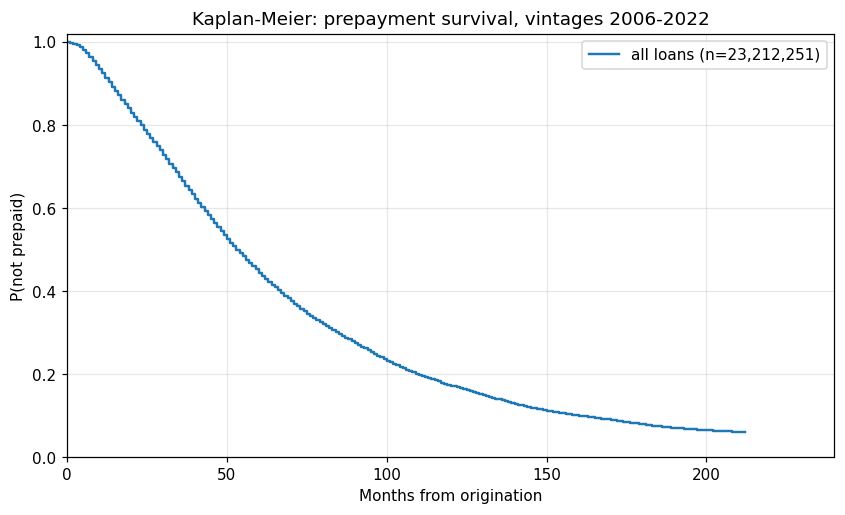

S( 12 mo) = 0.914
S( 36 mo) = 0.664
S( 60 mo) = 0.445
S(120 mo) = 0.173
S(180 mo) = 0.079


13

In [4]:
import gc

dur = loans["event_time_months"].to_numpy()
evt = loans["prepay_observed"].to_numpy()

# Lifetable-based KM: aggregated to one row per integer month, no n-length
# arrays retained. With n=13M the CI band is invisibly narrow anyway, so
# we plot just the point estimate.
table_agg = survival_table_from_events(dur, evt)
table_agg = table_agg[table_agg.index <= MAX_MONTHS]
hazard_agg = (table_agg["observed"] / table_agg["at_risk"]).rename("hazard")
S_agg = (1.0 - hazard_agg).cumprod().rename("survival")

fig, ax = plt.subplots(figsize=(9, 5))
ax.step(S_agg.index, S_agg.values, where="post", lw=1.6, label=f"all loans (n={len(dur):,})")
ax.set_xlim(0, MAX_MONTHS)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Months from origination")
ax.set_ylabel("P(not prepaid)")
ax.set_title(f"Kaplan-Meier: prepayment survival, vintages {YEARS[0]}-{YEARS[-1]}")
ax.grid(alpha=0.3); ax.legend()
fig.savefig(FIGURES_DIR / "partA_km_aggregate.png")
plt.show(); plt.close(fig)

# Quick reference points.
for t in (12, 36, 60, 120, 180):
    if t in S_agg.index:
        print(f"S({t:>3} mo) = {S_agg.loc[t]:.3f}")
    else:
        # nearest available month <= t
        avail = S_agg.index[S_agg.index <= t]
        if len(avail):
            print(f"S({t:>3} mo) ≈ {S_agg.loc[avail.max()]:.3f}  (at t={avail.max()})")

del dur, evt
gc.collect()

## (ii) Implied hazard rates

Two complementary views, both derived from the same lifetable as the KM
estimate:

- **Discrete monthly hazard** — at each integer month *t*, the share of
  still-active loans that prepay during month *t*. This is the natural unit
  for monthly panel data: `observed / at_risk`.
- **Smoothed monthly hazard** — centered rolling-mean smoother over the
  discrete series, easier to read trends from. The bandwidth is
  `SMOOTH_BW` months (window = 2·BW + 1).

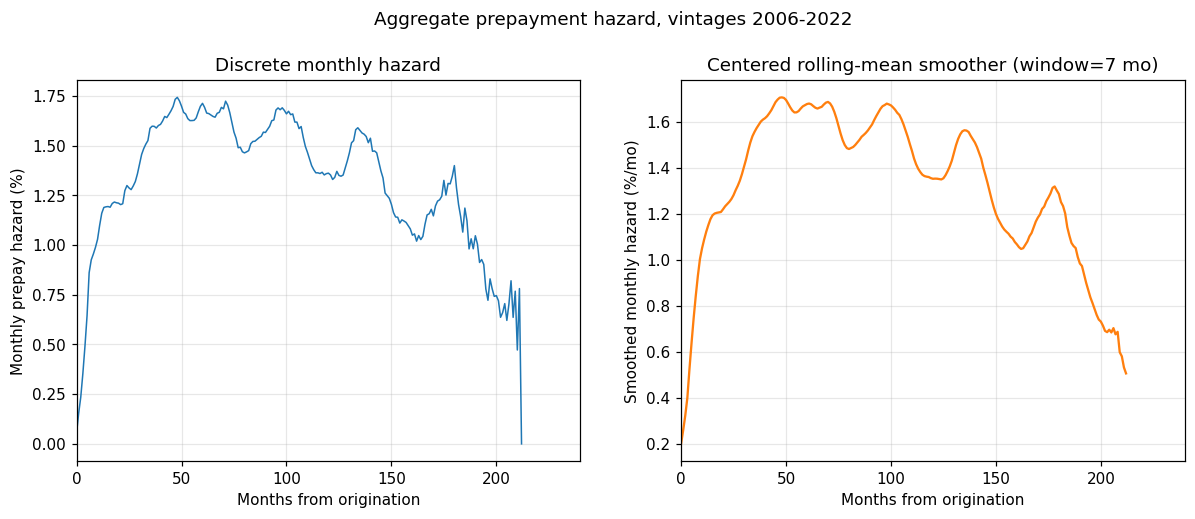

peak monthly hazard: 1.74% at month 48.0
hazard at 36 mo:     1.60%
hazard at 120 mo:    1.36%


9

In [5]:
# Discrete monthly hazard reuses the aggregate lifetable from the previous cell.
discrete_hazard = hazard_agg

# "Smoothed" hazard = centered rolling mean over the discrete monthly series.
# Same shape you would get from a Nelson-Aalen kernel smoother, without
# fitting a NelsonAalenFitter (which would retain n-length arrays).
window = max(1, 2 * SMOOTH_BW + 1)
smoothed = discrete_hazard.rolling(window=window, center=True, min_periods=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(discrete_hazard.index, discrete_hazard.values * 100, lw=1.0)
axes[0].set_xlabel("Months from origination")
axes[0].set_ylabel("Monthly prepay hazard (%)")
axes[0].set_title("Discrete monthly hazard")
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, MAX_MONTHS)

axes[1].plot(smoothed.index, smoothed.values * 100, lw=1.5, color="tab:orange")
axes[1].set_xlabel("Months from origination")
axes[1].set_ylabel("Smoothed monthly hazard (%/mo)")
axes[1].set_title(f"Centered rolling-mean smoother (window={window} mo)")
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, MAX_MONTHS)

fig.suptitle(f"Aggregate prepayment hazard, vintages {YEARS[0]}-{YEARS[-1]}", y=1.02)
fig.savefig(FIGURES_DIR / "partA_hazard_aggregate.png")
plt.show(); plt.close(fig)

print(f"peak monthly hazard: {discrete_hazard.max() * 100:.2f}% at month {discrete_hazard.idxmax()}")
print(f"hazard at 36 mo:     {discrete_hazard.get(36, float('nan')) * 100:.2f}%")
print(f"hazard at 120 mo:    {discrete_hazard.get(120, float('nan')) * 100:.2f}%")
gc.collect()

## (iii) Stratified survival and hazard by covariate

For each covariate (FICO, LTV, DTI, vintage group) we plot one panel:
**left** = KM survival curves stratified by bin, **right** = smoothed
Nelson-Aalen hazard for the same bins. Both saved to `figures/`.

The `plot_stratified` helper takes any covariate name in the dataframe and a
`{label: mask}` mapping, so you can drop in your own grouping at the bottom
of the notebook.

In [6]:
# Each call to plot_stratified appends a row to this list. The log-rank
# summary cell at the end just compiles them into a DataFrame.
LOGRANK_RESULTS: list[dict] = []


def _lifetable(durations: np.ndarray, events: np.ndarray, max_months: int):
    """Aggregated (events, at_risk, hazard, survival) — index = integer month.

    Uses lifelines\' survival_table_from_events, which produces a compact
    table with one row per unique observed/censoring time. We then trim to
    [0, max_months]. Memory footprint is O(unique times), NOT O(n) — this
    is the key trick that lets us stratify on 13M loans without blowing RAM.
    """
    table = survival_table_from_events(durations, events)
    table = table[table.index <= max_months]
    hazard = (table["observed"] / table["at_risk"]).rename("hazard")
    survival = (1.0 - hazard).cumprod().rename("survival")
    return hazard, survival


def plot_stratified(loans_df: pl.DataFrame, group_col: str, save_stem: str,
                    bin_cfg: dict | None = None,
                    explicit_groups: dict[str, pl.Expr] | None = None,
                    title: str | None = None,
                    smooth_bw: int = SMOOTH_BW, max_months: int = MAX_MONTHS,
                    sample_per_group: int | None = SAMPLE_PER_GROUP):
    """Plot KM + smoothed hazard stratified by `group_col`.

    Pass either `bin_cfg` (a {"breaks":[], "labels":[]} dict for numeric
    binning) or `explicit_groups` (a {label: polars-expression-mask} dict).

    Memory-friendly: each group is summarised to a small lifetable (one row
    per integer month), the lifelines fitters\' n-length internal arrays are
    never retained between iterations.
    """
    if bin_cfg is not None:
        df = (loans_df
              .filter(pl.col(group_col).is_not_null())
              .with_columns(pl.col(group_col)
                              .cut(breaks=bin_cfg["breaks"], labels=bin_cfg["labels"])
                              .alias("__grp")))
        ordered_groups = bin_cfg["labels"]
    elif explicit_groups is not None:
        cols = []
        ordered_groups = list(explicit_groups.keys())
        for label, mask in explicit_groups.items():
            cols.append(pl.when(mask).then(pl.lit(label)).otherwise(None))
        df = loans_df.with_columns(pl.coalesce(cols).alias("__grp")).filter(pl.col("__grp").is_not_null())
    else:
        raise ValueError("provide bin_cfg or explicit_groups")

    # Per-group sampling at the top so plotting and run_logrank operate on
    # exactly the same rows. No-op if sample_per_group is None.
    if sample_per_group is not None:
        parts = []
        for grp in ordered_groups:
            sub = df.filter(pl.col("__grp") == grp)
            if sub.height > sample_per_group:
                sub = sub.sample(n=sample_per_group, seed=0)
            parts.append(sub)
        df = pl.concat(parts)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    cmap = plt.cm.viridis(np.linspace(0.0, 0.9, len(ordered_groups)))
    window = max(1, 2 * smooth_bw + 1)   # centered-window length for the smoother

    for color, label in zip(cmap, ordered_groups):
        sub = df.filter(pl.col("__grp") == label)
        n_full = sub.height
        if n_full < 100:   # avoid noisy curves on tiny groups
            continue

        d = sub["event_time_months"].to_numpy()
        e = sub["prepay_observed"].to_numpy()

        hazard, survival = _lifetable(d, e, max_months)
        # Smooth the discrete hazard with a centered rolling mean. With monthly
        # data and a small bandwidth this matches the Nelson-Aalen kernel
        # smoother visually while costing nothing.
        smoothed = hazard.rolling(window=window, center=True, min_periods=1).mean()

        axes[0].step(survival.index, survival.values, where="post",
                     color=color, lw=1.4, label=f"{label} (n={n_full:,})")
        axes[1].plot(smoothed.index, smoothed.values * 100,
                     color=color, lw=1.4, label=label)

        # Release per-group state before the next iteration.
        del sub, d, e, hazard, survival, smoothed
        gc.collect()

    axes[0].set_xlim(0, max_months); axes[0].set_ylim(0, 1.02)
    axes[0].set_xlabel("Months from origination"); axes[0].set_ylabel("P(not prepaid)")
    axes[0].set_title(f"KM by {group_col}"); axes[0].grid(alpha=0.3); axes[0].legend()

    axes[1].set_xlim(0, max_months)
    axes[1].set_xlabel("Months from origination"); axes[1].set_ylabel("Smoothed hazard (%/mo)")
    axes[1].set_title(f"Hazard by {group_col}"); axes[1].grid(alpha=0.3); axes[1].legend()

    fig.suptitle(title or f"Prepayment by {group_col}", y=1.02)
    fig.savefig(FIGURES_DIR / f"partA_strat_{save_stem}.png")
    plt.show(); plt.close(fig)

    # Run log-rank on the same (possibly sampled) df we just plotted.
    # Project to the 3 needed columns BEFORE crossing into pandas.
    pdf = (df
           .select(["event_time_months", "prepay_observed", "__grp"])
           .drop_nulls()
           .to_pandas())
    res = multivariate_logrank_test(pdf["event_time_months"], pdf["__grp"], pdf["prepay_observed"])
    summary = {
        "covariate": save_stem,
        "n_groups": int(pdf["__grp"].nunique()),
        "n_loans":  int(len(pdf)),
        "chi2":     float(res.test_statistic),
        "p_value":  float(res.p_value),
    }
    LOGRANK_RESULTS.append(summary)
    print(f"  log-rank: chi2={summary['chi2']:.1f}  p={summary['p_value']:.2e}  "
          f"n_groups={summary['n_groups']}  n={summary['n_loans']:,}")

    # Aggressive cleanup — none of these are needed after the function returns.
    del df, pdf, res, fig, axes
    gc.collect()
    return summary

### FICO

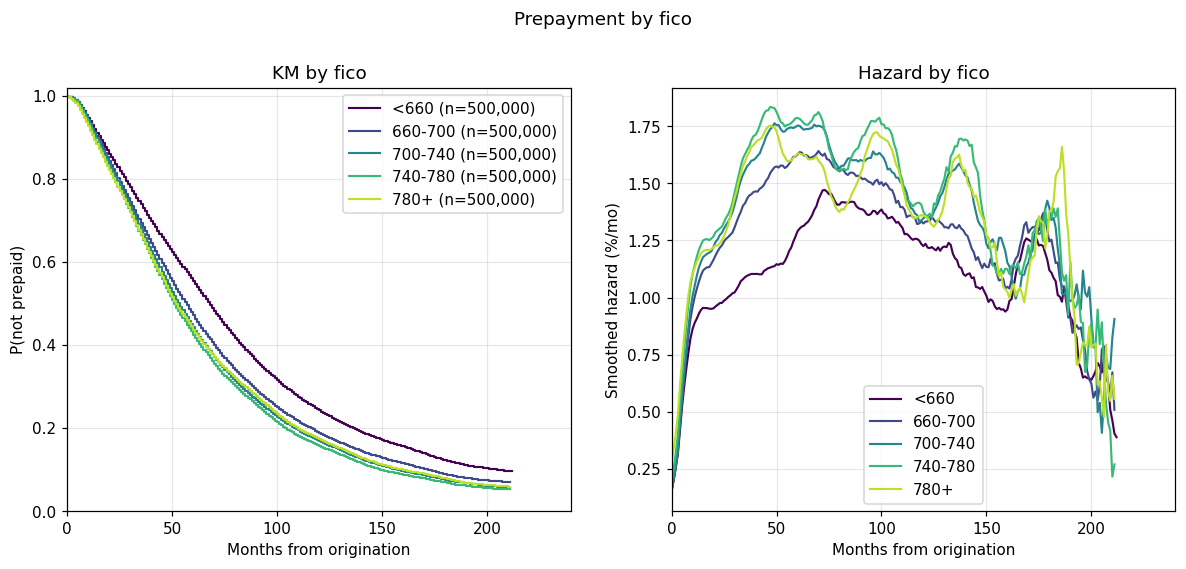

  log-rank: chi2=16423.1  p=0.00e+00  n_groups=5  n=2,500,000


In [7]:
plot_stratified(loans, "fico", save_stem="fico", bin_cfg=COVARIATE_BINS["fico"]);

### LTV

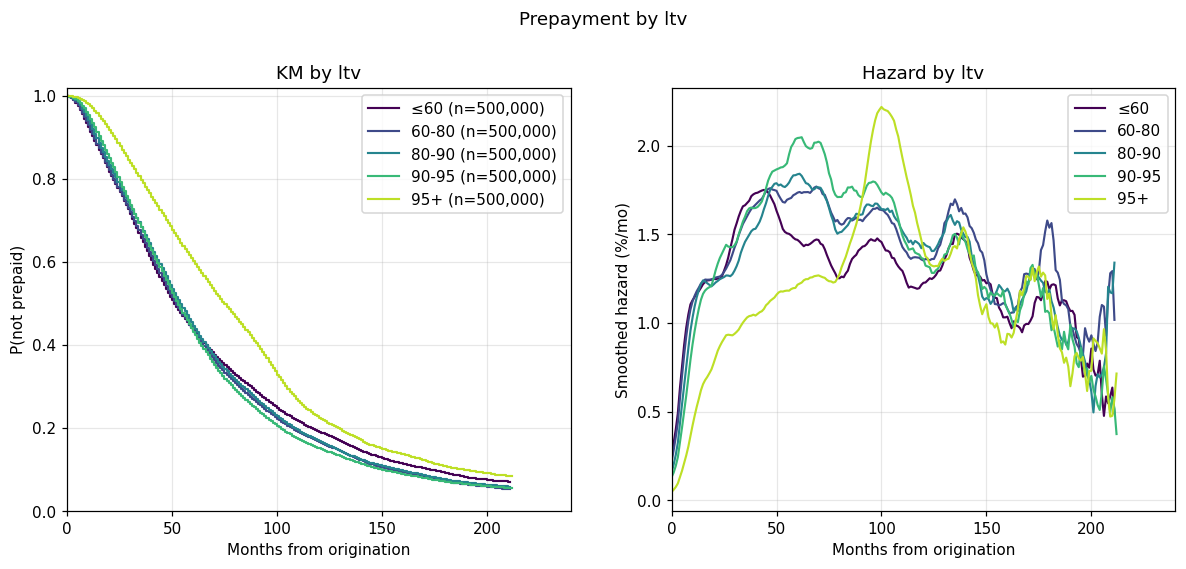

  log-rank: chi2=29693.4  p=0.00e+00  n_groups=5  n=2,500,000


In [8]:
plot_stratified(loans, "ltv", save_stem="ltv", bin_cfg=COVARIATE_BINS["ltv"]);

### DTI

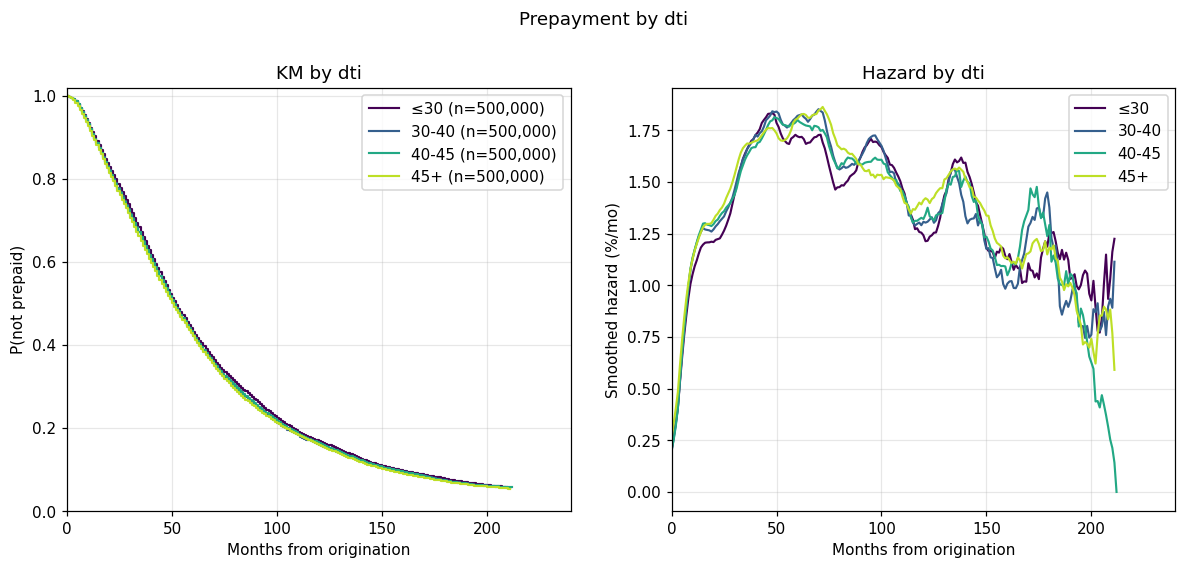

  log-rank: chi2=398.5  p=4.66e-86  n_groups=4  n=2,000,000


In [9]:
plot_stratified(loans, "dti", save_stem="dti", bin_cfg=COVARIATE_BINS["dti"]);

### Vintage group

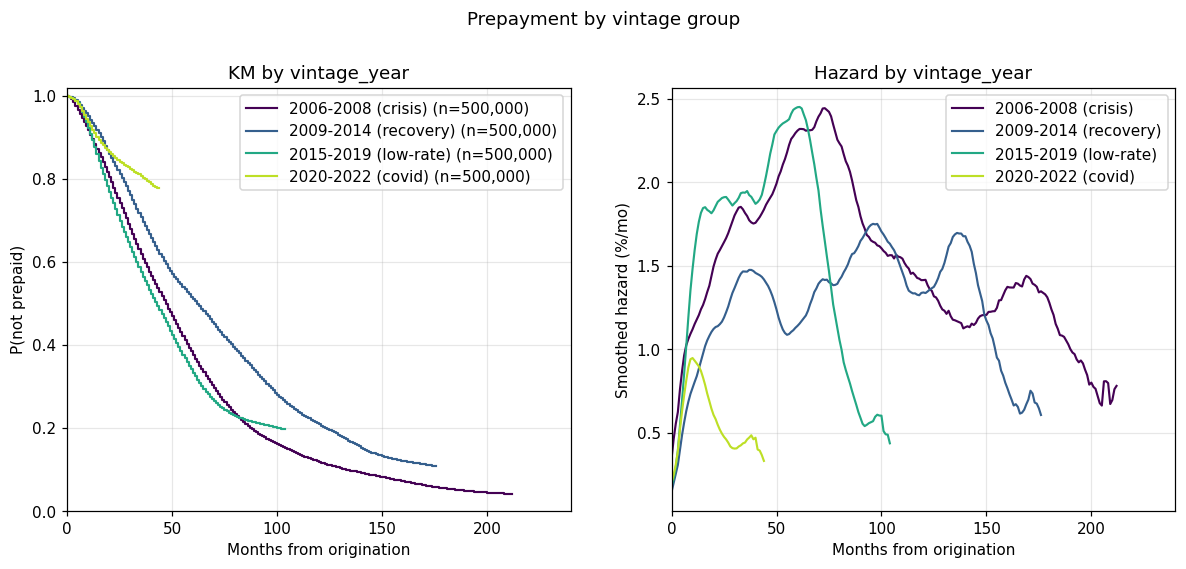

  log-rank: chi2=62588.2  p=0.00e+00  n_groups=4  n=2,000,000


In [10]:
vintage_groups_expr = {
    label: pl.col("vintage_year").is_in(years)
    for label, years in VINTAGE_GROUPS.items()
}
plot_stratified(loans, "vintage_year", save_stem="vintage",
                explicit_groups=vintage_groups_expr,
                title="Prepayment by vintage group");

## Statistical comparison panel — log-rank tests

Multivariate log-rank tests the null hypothesis that all groups share the
same survival curve. With ~10 million loans, p-values are nearly always 0;
the *test statistic* (chi-squared) is the comparable measure of how
strongly each covariate stratifies prepayment timing.

Higher chi-squared ⇒ stronger discrimination.

In [11]:
# LOGRANK_RESULTS was populated by each plot_stratified() call above.
results = (pd.DataFrame(LOGRANK_RESULTS)
             .sort_values("chi2", ascending=False)
             .reset_index(drop=True))
results_display = results.copy()
results_display["chi2"] = results_display["chi2"].round(1)
results_display["p_value"] = results_display["p_value"].apply(lambda p: f"{p:.2e}")
results_display.to_csv(FIGURES_DIR / "partA_logrank_results.csv", index=False)
print("saved:", FIGURES_DIR / "partA_logrank_results.csv")
results_display

saved: c:\Users\a\Desktop\Credit\Project2\figures\partA_logrank_results.csv


,covariate,n_groups,n_loans,chi2,p_value
0,vintage,4,2000000,62588.2,0.00e+00
1,ltv,5,2500000,29693.4,0.00e+00
2,fico,5,2500000,16423.1,0.00e+00
3,dti,4,2000000,398.5,4.66e-86


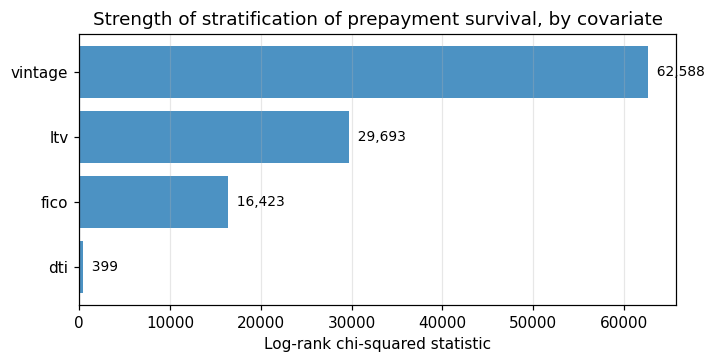

In [12]:
# Visual summary of the log-rank ranking — useful as a presentation slide.
# Use the unrounded `results` DataFrame so the bars are accurate.
fig, ax = plt.subplots(figsize=(7, 3.2))
order = results.sort_values("chi2")
ax.barh(order["covariate"], order["chi2"], color="tab:blue", alpha=0.8)
ax.set_xlabel("Log-rank chi-squared statistic")
ax.set_title("Strength of stratification of prepayment survival, by covariate")
for i, (cov, c) in enumerate(zip(order["covariate"], order["chi2"])):
    ax.text(c, i, f"  {c:,.0f}", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)
fig.savefig(FIGURES_DIR / "partA_logrank_summary.png")
plt.show(); plt.close(fig)

## How to customize

- **Different bins** — edit `COVARIATE_BINS` at the top of the notebook
  (`breaks` is the list of cut points, `labels` is one entry longer).
- **Different vintage groups** — edit `VINTAGE_GROUPS`.
- **Different time horizon** — change `MAX_MONTHS`.
- **Different smoother** — change `SMOOTH_BW` (months). Smoother curves use
  a wider centered rolling-mean window over the discrete monthly hazard.
- **Different vintages** — change `YEARS` (e.g. `[2006, 2007]` for a quick
  iteration, or include 2024-2025 for held-out evaluation).
- **Tight RAM** — set `SAMPLE_PER_GROUP = 500_000` (or smaller). The
  stratified curves are computed from a per-group sample; KM converges to
  the population curve well below a million observations, so visual
  resolution is unchanged. Log-rank chi-squared scales with *n* uniformly,
  so cross-covariate ranking is preserved.
- **A different covariate entirely** — call `plot_stratified(loans,
  "your_col", save_stem="your_col", bin_cfg={"breaks":[...], "labels":[...]})`
  in a fresh cell. As long as the column is in the loaded `loans` frame, it
  works.

## Saved artifacts (for the presentation)

```
figures/
├── partA_km_aggregate.png
├── partA_hazard_aggregate.png
├── partA_strat_fico.png
├── partA_strat_ltv.png
├── partA_strat_dti.png
├── partA_strat_vintage.png
├── partA_logrank_summary.png
└── partA_logrank_results.csv
```